# Naive Optimised Root X Scaling figure
- create figure showing the infidelity scaling with second qubit detuning of the identity gate for rabi and ccd schemes
- should be general - ie interms of rabi frequency
- should be pretty - with descriptive title etc

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [4]:
steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


# CCD - Optimised first

In [4]:
import numpy as np
from scipy.optimize import minimize



# Create a quantum system with a single qubit
natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz

# note that we are setting phase_freq to rabi_freq/16
# we are also setting theta_m to pi2
# as well as phi_0 
phi_0, epsilon_m, phase_freq, theta_m = np.pi/2, rabi_freq/4, rabi_freq, np.pi/2


evaluation_points = 100000
evaluation_time = 4/rabi_freq
tol = 10**-12

# Define target root-X gate
root_x = (1 / np.sqrt(2)) * np.array([[1, -1j], [-1j, 1]])

# Objective function: 1 - fidelity (since we are minimising)
def objective(params):
    epsilon_m, phi, theta, detuning = params

    try:
        _, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points,hamiltonians.ccd_rwa,
                        driving_freq=driving_freq+detuning*rabi_freq,
                        natural_freq=natural_freq, rabi_freq=rabi_freq, phi_0=phi*np.pi,
                        epsilon_m=epsilon_m*rabi_freq,
                        phase_freq=phase_freq,
                        theta_m=theta*np.pi,
                        rtol=tol, atol = tol)
       
        fid = qt.calculate_fidelities(root_x, Us_driving_frame, 2)
        return 1 - fid[-1]  # We want to maximise fidelity, so minimise 1 - fidelity

    except Exception as e:
        print(f"Error during evaluation: {e}")
        return 1  # Return high loss if something breaks

# Initial guess and bounds
initial_guess = [1/16, 1/2, -1/2, 0]
bounds = [(1/16, 1/16), (-2, 2), (-2, 2), (-0.000, 0.000)]

# Run optimisation
result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')

# Extract and print optimal values
optimal_epsilon_m, optimal_phi, optimal_theta, optimal_detuning= result.x
optimal_fidelity = 1 - result.fun

print(f"✅ Optimal εₘ: {optimal_epsilon_m} x Ω ")
print(f"✅ Optimal φ: {optimal_phi} x π ")
print(f"✅ Optimal θ: {optimal_theta} x π ")
print(f"✅ Optimal detuning: {optimal_detuning} x Ω ")
print(f"🎯 Max Fidelity: {optimal_fidelity}")

✅ Optimal εₘ: 0.0625 x Ω 
✅ Optimal φ: 0.48507178492998143 x π 
✅ Optimal θ: -0.49999999968816566 x π 
✅ Optimal detuning: -0.0 x Ω 
🎯 Max Fidelity: 0.9999999938552416


In [5]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)

fids_1 = []
fids_2 = []
fids_combined = []

# First calculate fidelity for qubit 1 (root-x gate)
times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m)
fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:
    fids_1.append(fid_1)
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    
    # Calculate combined fidelity
    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_ccd = [fid[-1] for fid in fids_combined]

KeyboardInterrupt: 

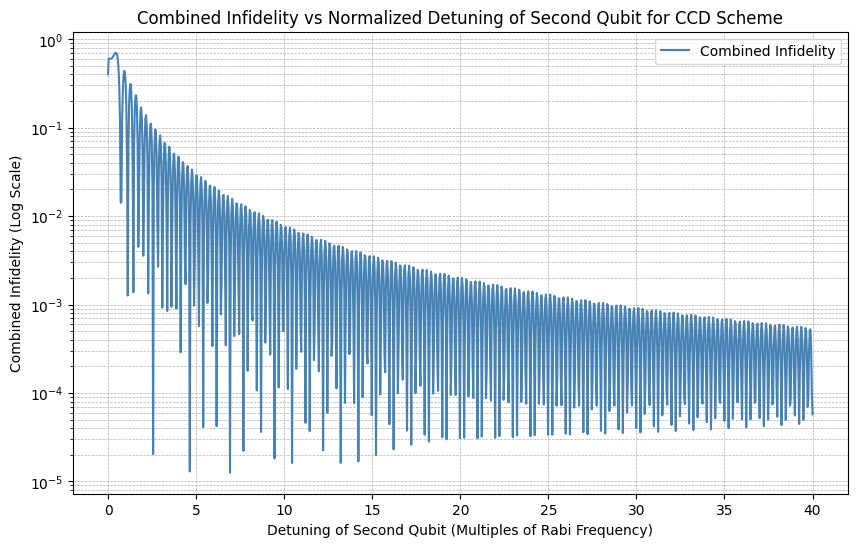

In [8]:
# find combdined infidelity
infidelities_combined_ccd = 1-np.array(final_fids_combined_ccd)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


# Rabi
- note we acc want to try with normal time taking and then match it to ccd root x time

In [9]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 1/(4*rabi_freq)

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)



fids_1 = []
fids_2 = []
fids_combined = []

times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+0, driving_freq=driving_freq, rabi_freq=rabi_freq)
fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)


for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)

    fids_1.append(fid_1)

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)

    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_rabi = [fid[-1] for fid in fids_combined]


KeyboardInterrupt: 

In [27]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005/16



# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)



fids_1 = []
fids_2 = []
fids_combined = []

times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+0, driving_freq=driving_freq, rabi_freq=rabi_freq)
fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)


for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)

    fids_1.append(fid_1)

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)

    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_rabi_longer = [fid[-1] for fid in fids_combined]


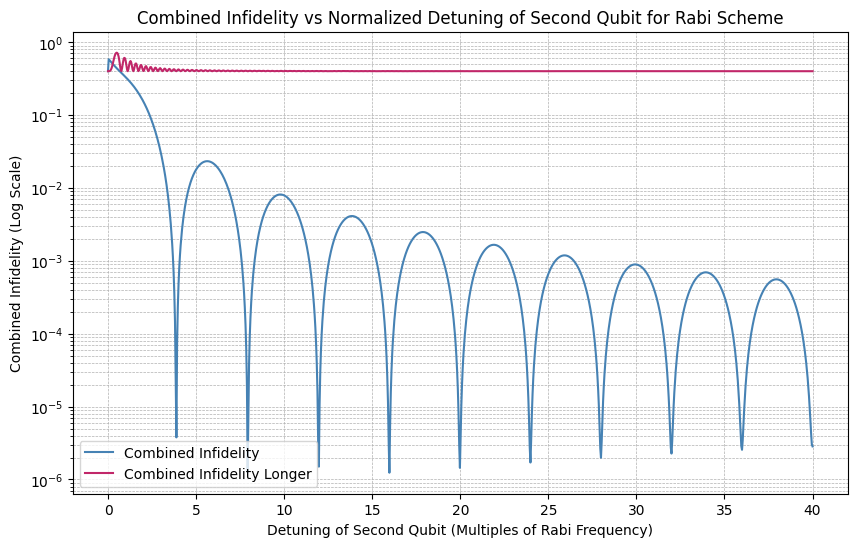

In [28]:
# find combdined infidelity
infidelities_combined_rabi = 1-np.array(final_fids_combined_rabi)
infidelities_combined_rabi_longer = 1-np.array(final_fids_combined_rabi_longer)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Combined Infidelity", color=steel_blue)
plt.semilogy(detunings_normalized, infidelities_combined_rabi_longer, label="Combined Infidelity Longer", color=deep_magenta)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for Rabi Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


# Combined

In [17]:
deep_magenta = "#C12769"

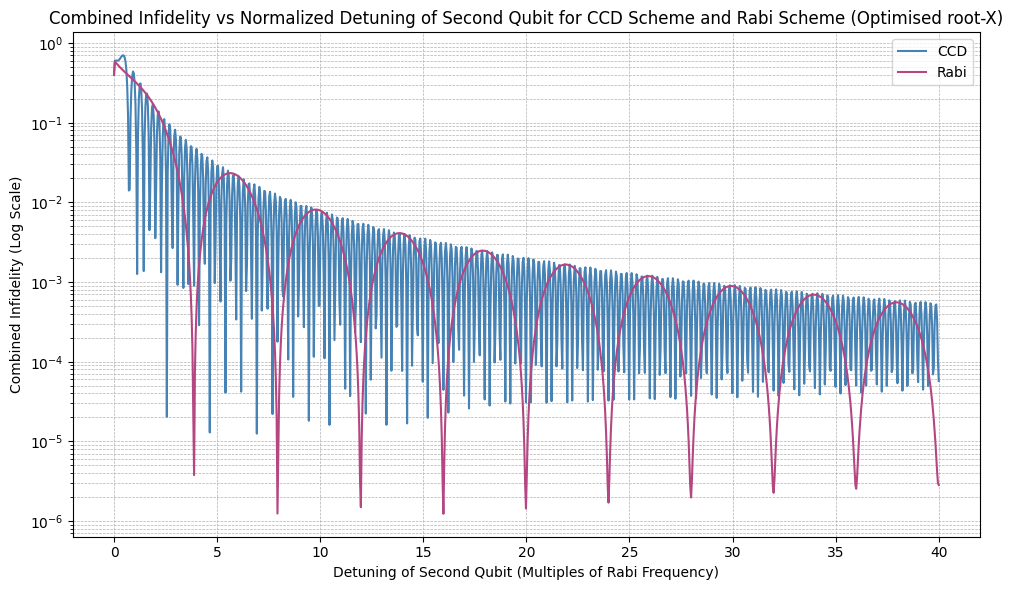

In [26]:
# find combdined infidelity
infidelities_combined_ccd = 1-np.array(final_fids_combined_ccd)
infidelities_combined_rabi = 1-np.array(final_fids_combined_rabi)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="CCD", color=steel_blue)
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Rabi", color=plum)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Optimised root-X)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig("dirty_root_x_scaling.png", dpi=300)
plt.show()

